In [ ]:
# Bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
# Carregar os dados
df = pd.read_csv('../../Data/PROCESSED/leads_processados_para_pbi.csv')

# Converter a variável target
df['target'] = df['status_conversao'].map({'Convertido': 1, 'Não Convertido': 0})

# Criar a variável binária 'converteu'
df['converteu'] = df['dias_ate_1o_trade'].notna().astype(int)

In [20]:
# Confirma que a coluna alvo está binária
df['converteu'] = df['converteu'].astype(int)

# 🎯 Embedding supervisionado: taxa de conversão por país
taxa_conversao_pais = df.groupby("pais")['converteu'].mean()

# Merge no dataframe original
df['pais_embedding'] = df['pais'].map(taxa_conversao_pais)

# Substitui valores ausentes (caso algum país não esteja mapeado)
df['pais_embedding'] = df['pais_embedding'].fillna(df['pais_embedding'].mean())

# Remove a coluna original
df = df.drop(columns=['pais'])

In [21]:
df.head(5)

,lead_id,origem,data_cadastro,status_conversao,dias_ate_1o_trade,valor_deposito,perfil,foi_convertido,ano_mes_cadastro,target,converteu,pais_embedding
0,210428,Instagram,2025-01-07,Não Convertido,NaN,0.0,Moderado,False,2025-01,0,0,0.044592
1,210429,E-mail Marketing,2025-01-08,Não Convertido,NaN,0.0,Agressivo,False,2025-01,0,0,0.061224
2,210430,Instagram,2025-01-07,Não Convertido,NaN,0.0,Moderado,False,2025-01,0,0,0.047704
3,210431,Orgânico,2025-01-10,Não Convertido,NaN,0.0,Conservador,False,2025-01,0,0,0.055111
4,210432,YouTube Ads,2025-01-11,Não Convertido,NaN,0.0,Conservador,False,2025-01,0,0,0.038710


In [22]:
df_model = df.drop(columns=[
     'foi_convertido', 'status_conversao', 'ano_mes_cadastro', 'data_cadastro'
])

In [23]:
# One-hot encoding para variáveis categóricas
df_model = pd.get_dummies(df_model, columns=['origem', 'perfil'], drop_first=True)


In [24]:
# Calcula a média apenas dos que fizeram trade
media_convertidos = df_model.loc[df_model['converteu'] == 1, 'dias_ate_1o_trade'].mean()

# Preenche os NaNs com essa média
df_model['dias_ate_1o_trade'] = df_model['dias_ate_1o_trade'].fillna(media_convertidos)


In [25]:


scaler = StandardScaler()
df_model[['valor_deposito', 'pais_embedding']] = scaler.fit_transform(df_model[['valor_deposito', 'pais_embedding']])


In [26]:
X = df_model.drop(columns='converteu')
y = df_model['converteu']

In [27]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

c:\Users\leojo\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\leojo\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\leojo\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\leojo\AppData\Local\Programs\Python\Python313\Lib\subprocess.py",

In [29]:


lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test)
print("🔍 Regressão Logística")
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_pred_lr))


🔍 Regressão Logística
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50796
           1       1.00      1.00      1.00      2694

    accuracy                           1.00     53490
   macro avg       1.00      1.00      1.00     53490
weighted avg       1.00      1.00      1.00     53490

AUC: 0.9992576095025983


c:\Users\leojo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:


rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test)
print("🌲 Random Forest")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_pred_rf))


🌲 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50796
           1       1.00      1.00      1.00      2694

    accuracy                           1.00     53490
   macro avg       1.00      1.00      1.00     53490
weighted avg       1.00      1.00      1.00     53490

AUC: 1.0


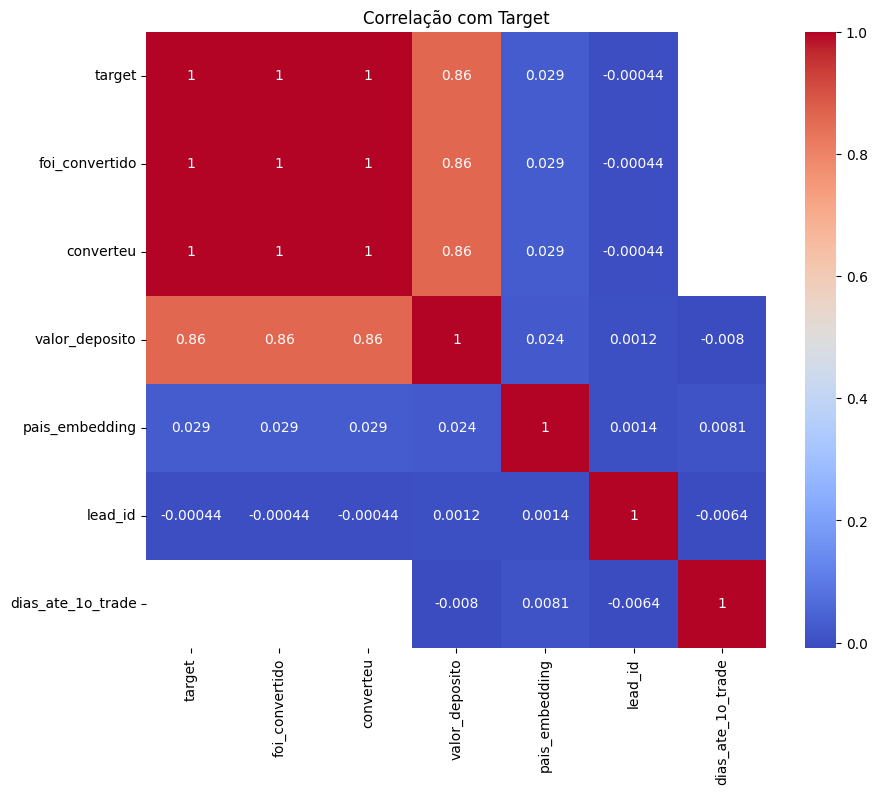

In [32]:

# Heatmap da correlação
corr_target = df.corr(numeric_only=True)['target'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_target.index].corr(), annot=True, cmap='coolwarm')
plt.title("Correlação com Target")
plt.show()



In [33]:
colunas_remover = [
    'lead_id', 
    'data_cadastro', 
    'ano_mes_cadastro',
    'valor_deposito',          # pós-conversão
    'dias_ate_1o_trade',       # só existe para convertidos
    'converteu',               # criado com base na conversão
    'status_conversao',        # duplicata semântica do target
    'target'                   # target não vai no X
]

X = df.drop(columns=colunas_remover)
y = df['target']


In [35]:
# Codificação de variáveis categóricas
X_encoded = pd.get_dummies(X, drop_first=True)

# Treino/teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, stratify=y, random_state=42)

# Padronização
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
model.fit(X_train_res, y_train_res)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     63495
           1       1.00      1.00      1.00      3367

    accuracy                           1.00     66862
   macro avg       1.00      1.00      1.00     66862
weighted avg       1.00      1.00      1.00     66862

AUC: 0.9999999999999999


In [44]:
df_model

,lead_id,dias_ate_1o_trade,valor_deposito,target,converteu,pais_embedding,origem_Facebook,origem_Google Ads,origem_Indicação,origem_Instagram,origem_Orgânico,origem_TikTok,origem_WhatsApp,origem_YouTube Ads,perfil_Conservador,perfil_Desconhecido,perfil_Moderado
0,210428,15.008539,-0.198326,0,0,-0.920248,False,False,False,True,False,False,False,False,False,False,True
1,210429,15.008539,-0.198326,0,0,1.734542,False,False,False,False,False,False,False,False,False,False,False
2,210430,15.008539,-0.198326,0,0,-0.423536,False,False,False,True,False,False,False,False,False,False,True
3,210431,15.008539,-0.198326,0,0,0.758755,False,False,False,False,True,False,False,False,True,False,False
4,210432,15.008539,-0.198326,0,0,-1.859160,False,False,False,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267443,59949,15.008539,-0.198326,0,0,1.123953,False,True,False,False,False,False,False,False,False,False,False
267444,59950,15.008539,-0.198326,0,0,1.737520,False,False,False,False,False,False,False,False,False,False,False
267445,59951,15.008539,-0.198326,0,0,1.281699,False,False,False,False,False,True,False,False,False,False,False
267446,59952,15.008539,-0.198326,0,0,0.038769,False,False,False,False,False,False,True,False,False,False,False


In [40]:
# 🔹 Variáveis a serem removidas para evitar overfitting
cols_to_drop = ['lead_id', 'valor_deposito', 'dias_ate_1o_trade', 'target', 'converteu']

# 🔹 Definir X e y
X = df_model.drop(columns=cols_to_drop)
y = df_model['target']

# 🔹 Separar em treino/teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# 🔹 Padronização
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 Avaliar modelos novamente (por exemplo, regressão logística)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]

print("🔍 Regressão Logística após correção")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))


🔍 Regressão Logística após correção
              precision    recall  f1-score   support

           0       0.95      0.54      0.69     63495
           1       0.06      0.51      0.10      3367

    accuracy                           0.53     66862
   macro avg       0.50      0.52      0.39     66862
weighted avg       0.91      0.53      0.66     66862

AUC: 0.5294515612020927


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Balancear os dados
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 2. Treinar o modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_resampled, y_train_resampled)

# 3. Previsões
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# 4. Resultados
print("🌲 Random Forest (com SMOTE)")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))

🌲 Random Forest (com SMOTE)
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     63495
           1       0.05      0.13      0.07      3367

    accuracy                           0.83     66862
   macro avg       0.50      0.50      0.49     66862
weighted avg       0.90      0.83      0.87     66862

AUC: 0.49885102117561364


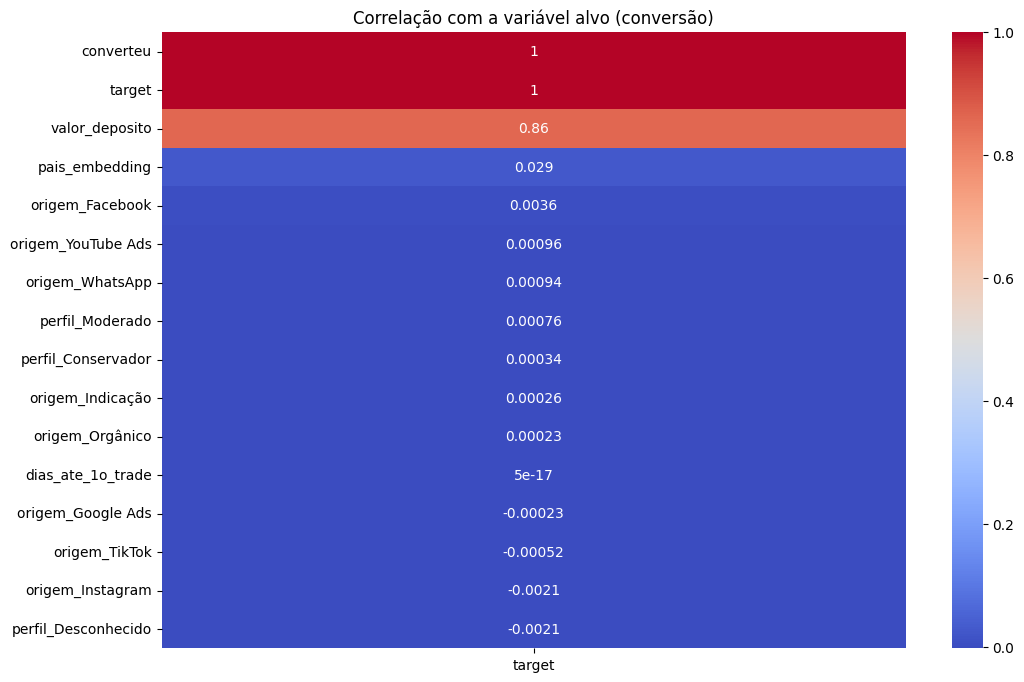

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_model.drop(columns=['lead_id']).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr[['target']].sort_values(by='target', ascending=False), annot=True, cmap='coolwarm')
plt.title("Correlação com a variável alvo (conversão)")
plt.show()


In [43]:
from datetime import datetime

# 🔁 1. Tempo desde o cadastro
df_model['data_cadastro'] = pd.to_datetime(df_model['data_cadastro'], errors='coerce')
data_atual = pd.to_datetime(datetime.today().date())
df_model['tempo_desde_cadastro'] = (data_atual - df_model['data_cadastro']).dt.days

# 🗓️ 2. Mês do cadastro (sazonalidade)
df_model['mes_cadastro'] = df_model['data_cadastro'].dt.month

# ⏳ 3. Dias sem conversão (apenas para leads não convertidos)
df_model['dias_sem_conversao'] = df_model.apply(
    lambda row: row['tempo_desde_cadastro'] if row['target'] == 0 else 0,
    axis=1
)


KeyError: 'data_cadastro'